# Field-Line Inclination at a Chosen Height

This notebook computes the angle between the local magnetic field direction and a chosen line of sight (LOS). Because magnetic field lines are tangent to the magnetic field vector, the field-line inclination at a point is the angle between **B** and the LOS vector.

By default, this notebook loads the extrapolation saved by `main.ipynb` at `examples/extrapolations/rtmag_extrapolation_for_inclination.npz`. If that file is not present yet, set `data_mode = "analytic"` to run the standalone Low and Lou example.

## Definition

For a magnetic field vector **B** = (`Bx`, `By`, `Bz`) and a unit line-of-sight vector **l**, the inclination is

$$\theta = \cos^{-1}\left(\frac{\mathbf{B}\cdot\mathbf{l}}{|\mathbf{B}|}\right).$$

If `use_absolute_los_angle = True`, the notebook uses `abs(B dot l)` and reports the acute angle in the range 0-90 degrees. This answers "how aligned is the field line with the LOS?" independent of magnetic polarity. If you want polarity-sensitive angles, set it to `False` to get 0-180 degrees.

In [89]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import sunpy.map
from scipy.interpolate import RegularGridInterpolator

plt.rcParams.update({"figure.dpi": 120})

## User Inputs

By default this notebook opens the latest case exported by `main.ipynb`, using `examples/analysis_exports/latest_case.txt`. Enter the requested height as `height_Mm`; the notebook converts that physical height to the z coordinate used by the loaded field. The saved HMI reference FITS map provides the WCS template for the inclination SunPy `Map`.

In [90]:
# Use "case" for the organized folder exported by main.ipynb, or "analytic" for a standalone demo.
data_mode = "case"

# When case_dir is None, the notebook reads this pointer written by main.ipynb.
latest_case_file = Path("examples/analysis_exports/latest_case.txt")
case_dir = None

# Optional manual overrides. Leave these as None for the exported case layout.
npz_path = None
reference_map_path = None
npz_key = "b"

# Requested physical height above the bottom boundary.
height_Mm = 1.5

# Leave these as None to use x_coords, y_coords, z_coords from the exported file.
x_coords = None
y_coords = None
z_coords = None

# AIA wavelength to open from the saved reprojected AIA maps, if available.
aia_wavelength_for_comparison = 171

# Line of sight. For disk-center viewing with z vertical, use [0, 0, 1].
los_vector = np.array([0.0, 0.0, 1.0])

# True gives 0-90 deg alignment angle; False gives polarity-sensitive 0-180 deg angle.
use_absolute_los_angle = True

# Optional point sample on the selected height plane, in the same units as x_coords/y_coords.
x_sample = None
y_sample = None

## Helper Functions

In [91]:
def normalize_vector(vector):
    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)
    if norm == 0:
        raise ValueError("LOS vector must be non-zero.")
    return vector / norm


def as_field_volume(array):
    """Return a magnetic-field array with shape (nx, ny, nz, 3)."""
    array = np.asarray(array)
    while array.ndim > 4 and array.shape[0] == 1:
        array = array[0]
    if array.ndim != 4:
        raise ValueError(f"Expected a 4D magnetic-field array, got shape {array.shape}.")
    if array.shape[-1] == 3:
        return array.astype(np.float32)
    if array.shape[0] == 3:
        return np.moveaxis(array, 0, -1).astype(np.float32)
    raise ValueError(
        "Could not identify the vector-component axis. Expected shape (nx, ny, nz, 3) "
        f"or (3, nx, ny, nz), got {array.shape}."
    )


def resolve_case_paths(data_mode, case_dir, latest_case_file, npz_path, reference_map_path):
    """Resolve paths for either an organized exported case or a standalone npz.

    Behavior:
    - data_mode == "case":
      - If case_dir is provided: use it.
      - Else try latest_case_file.
      - If latest_case_file is missing: automatically fall back to legacy npz export.
    - data_mode == "npz": use npz_path or legacy default.
    - data_mode == "analytic": no paths.
    """

    legacy_npz = Path("examples/extrapolations/rtmag_extrapolation_for_inclination.npz")

    if data_mode == "case":
        if case_dir is None:
            latest_case_file = Path(latest_case_file)
            if not latest_case_file.exists():
                # Robust fallback: many users will have the legacy export but not the new case folder.
                if legacy_npz.exists():
                    print(
                        f"{latest_case_file} not found. Falling back to legacy export: {legacy_npz}. "
                        "Run the export cell in main.ipynb to enable full WCS/case-based workflow."
                    )
                    return None, legacy_npz, None

                raise FileNotFoundError(
                    f"{latest_case_file} was not found, and no legacy export was found at {legacy_npz}. "
                    "Run the export cell in main.ipynb first, or set data_mode = 'analytic'."
                )

            case_dir = Path(latest_case_file.read_text().strip())
        else:
            case_dir = Path(case_dir)

        if npz_path is None:
            npz_path = case_dir / "extrapolation" / "rtmag_extrapolation.npz"
        if reference_map_path is None:
            reference_map_path = case_dir / "maps" / "hmi" / "hmi_reference_model_grid.fits"

    elif data_mode == "npz":
        case_dir = Path(case_dir) if case_dir is not None else None
        if npz_path is None:
            npz_path = legacy_npz
        reference_map_path = Path(reference_map_path) if reference_map_path is not None else None

    else:
        # analytic mode
        case_dir = None
        npz_path = None
        reference_map_path = None

    return case_dir, Path(npz_path) if npz_path is not None else None, Path(reference_map_path) if reference_map_path is not None else None



def load_npz_field(path, key=None):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{path} was not found.")

    metadata = {}
    with np.load(path, allow_pickle=True) as data:
        keys = list(data.keys())
        if key is None:
            candidates = ["b", "B", "field", "label", "pred", "output", "arr_0"]
            key = next((candidate for candidate in candidates if candidate in keys), None)
            if key is None:
                raise KeyError(f"Could not auto-detect a field key. Available keys: {keys}")
        if key not in keys:
            raise KeyError(f"Key {key!r} not found. Available keys: {keys}")

        field = as_field_volume(data[key])
        for coord_key in ("x_coords", "y_coords", "z_coords"):
            if coord_key in keys:
                metadata[coord_key] = np.asarray(data[coord_key], dtype=float)
        for scalar_key in ("dx", "dy", "dz", "dx_Mm", "dy_Mm", "dz_Mm"):
            if scalar_key in keys:
                metadata[scalar_key] = float(np.asarray(data[scalar_key]))
        for text_key in ("units", "coordinate_units", "field_units", "case_dir", "hmi_reference_map_path"):
            if text_key in keys:
                metadata[text_key] = str(np.asarray(data[text_key]).item())

    print(f"Loaded {path} key={key!r} with B shape {field.shape}")
    return field, metadata


def default_coords(B):
    nx, ny, nz, _ = B.shape
    return np.arange(nx, dtype=float), np.arange(ny, dtype=float), np.arange(nz, dtype=float)


def height_mm_to_z_coordinate(height_Mm, z_coords, metadata):
    coordinate_units = str(metadata.get("coordinate_units", metadata.get("units", "grid_index")))
    if coordinate_units.lower() == "mm":
        z_coordinate = float(height_Mm)
        conversion_note = "z_coords are already in Mm"
    else:
        dz_Mm = metadata.get("dz_Mm", metadata.get("dz"))
        if dz_Mm is None:
            raise ValueError(
                "Cannot convert height_Mm because this file does not provide physical z coordinates "
                "or dz_Mm metadata. Provide z_coords in Mm or save dz_Mm in the NPZ."
            )
        z_coordinate = float(height_Mm) / float(dz_Mm)
        conversion_note = f"converted height_Mm / dz_Mm using dz_Mm = {dz_Mm:g} Mm"

    if not (z_coords.min() <= z_coordinate <= z_coords.max()):
        raise ValueError(
            f"height_Mm={height_Mm} maps to z={z_coordinate:g}, outside the z range "
            f"[{z_coords.min():g}, {z_coords.max():g}] in coordinate units {coordinate_units}."
        )
    nearest_index = int(np.argmin(np.abs(z_coords - z_coordinate)))
    return z_coordinate, coordinate_units, conversion_note, nearest_index


def plane_at_height(B, x_coords, y_coords, z_coords, height):
    if not (z_coords.min() <= height <= z_coords.max()):
        raise ValueError(
            f"height={height} is outside the z range [{z_coords.min()}, {z_coords.max()}]."
        )

    x_grid, y_grid = np.meshgrid(x_coords, y_coords, indexing="ij")
    points = np.column_stack([
        x_grid.ravel(),
        y_grid.ravel(),
        np.full(x_grid.size, height, dtype=float),
    ])

    components = []
    for component in range(3):
        interp = RegularGridInterpolator(
            (x_coords, y_coords, z_coords),
            B[..., component],
            bounds_error=True,
        )
        components.append(interp(points).reshape(len(x_coords), len(y_coords)))

    return np.stack(components, axis=-1)


def inclination_degrees(B_plane, los_vector, acute=True):
    los_hat = normalize_vector(los_vector)
    B_norm = np.linalg.norm(B_plane, axis=-1)
    dot = np.einsum("...i,i->...", B_plane, los_hat)
    cos_theta = np.full_like(B_norm, np.nan, dtype=float)
    valid = B_norm > 0
    cos_theta[valid] = dot[valid] / B_norm[valid]
    if acute:
        cos_theta = np.abs(cos_theta)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))


def map_from_model_plane(data_xy, template_map, bunit=None, name=None):
    meta = template_map.meta.copy()
    if bunit is not None:
        meta["bunit"] = bunit
    if name is not None:
        meta["content"] = name
    return sunpy.map.Map(np.asarray(data_xy, dtype=np.float32).T, meta)


## Load the Case and Magnetic Field

For `data_mode = "case"`, this reads the latest exported case folder, the extrapolated field, and the HMI reference map whose WCS matches the model grid. The HMI reference map is used as the WCS template for the inclination map.

In [92]:
npz_metadata = {}
case_dir, resolved_npz_path, resolved_reference_map_path = resolve_case_paths(
    data_mode, case_dir, latest_case_file, npz_path, reference_map_path
)

if data_mode == "analytic":
    from rtmag.process.paper.analytical_field import get_analytic_b_field

    B = get_analytic_b_field(
        n=1,
        m=1,
        l=0.3,
        psi=np.pi / 4,
        resolution=[96, 96, 64],
        bounds=[-1, 1, -1, 1, 0, 2],
    )
    x_coords = np.linspace(-1, 1, B.shape[0])
    y_coords = np.linspace(-1, 1, B.shape[1])
    z_coords = np.linspace(0, 2, B.shape[2])
    npz_metadata = {"coordinate_units": "model units"}
    reference_map = None
elif data_mode in ("case", "npz"):
    B, npz_metadata = load_npz_field(resolved_npz_path, npz_key)
    x_default, y_default, z_default = default_coords(B)
    x_coords = npz_metadata.get("x_coords", x_default) if x_coords is None else x_coords
    y_coords = npz_metadata.get("y_coords", y_default) if y_coords is None else y_coords
    z_coords = npz_metadata.get("z_coords", z_default) if z_coords is None else z_coords

    if resolved_reference_map_path is None and "hmi_reference_map_path" in npz_metadata:
        resolved_reference_map_path = Path(npz_metadata["hmi_reference_map_path"])
    reference_map = sunpy.map.Map(resolved_reference_map_path) if resolved_reference_map_path and Path(resolved_reference_map_path).exists() else None
else:
    raise ValueError("data_mode must be 'case', 'npz', or 'analytic'.")

B = as_field_volume(B)
x_coords = np.asarray(x_coords, dtype=float)
y_coords = np.asarray(y_coords, dtype=float)
z_coords = np.asarray(z_coords, dtype=float)

height, z_coordinate_units, height_conversion_note, nearest_z_index = height_mm_to_z_coordinate(
    height_Mm, z_coords, npz_metadata
)

print(f"case_dir: {case_dir}")
print(f"B shape: {B.shape} = (nx, ny, nz, components)")
print(f"x range: {x_coords.min():.3g} to {x_coords.max():.3g} {z_coordinate_units}")
print(f"y range: {y_coords.min():.3g} to {y_coords.max():.3g} {z_coordinate_units}")
print(f"z range: {z_coords.min():.3g} to {z_coords.max():.3g} {z_coordinate_units}")
print(f"requested height: {height_Mm:g} Mm")
print(f"interpolator z coordinate: {height:g} {z_coordinate_units} ({height_conversion_note})")
print(f"nearest z grid index: {nearest_z_index}, z = {z_coords[nearest_z_index]:.3g} {z_coordinate_units}")
print(f"reference map: {resolved_reference_map_path if reference_map is not None else None}")

examples/analysis_exports/latest_case.txt not found. Falling back to legacy export: examples/extrapolations/rtmag_extrapolation_for_inclination.npz. Run the export cell in main.ipynb to enable full WCS/case-based workflow.
Loaded examples/extrapolations/rtmag_extrapolation_for_inclination.npz key='b' with B shape (512, 256, 256, 3)
case_dir: None
B shape: (512, 256, 256, 3) = (nx, ny, nz, components)
x range: 0 to 250 Mm
y range: 0 to 163 Mm
z range: 0 to 163 Mm
requested height: 1.5 Mm
interpolator z coordinate: 1.5 Mm (z_coords are already in Mm)
nearest z grid index: 2, z = 1.28 Mm
reference map: None


## Compute Inclination at the Requested Height

In [93]:
B_height = plane_at_height(B, x_coords, y_coords, z_coords, height)
inclination = inclination_degrees(
    B_height,
    los_vector=los_vector,
    acute=use_absolute_los_angle,
)

print(f"requested height = {height_Mm:g} Mm")
print(f"interpolator z = {height:g} {z_coordinate_units}")
print(f"LOS unit vector = {normalize_vector(los_vector)}")
print(f"inclination range = {np.nanmin(inclination):.2f} to {np.nanmax(inclination):.2f} deg")
print(f"mean inclination = {np.nanmean(inclination):.2f} deg")
print(f"median inclination = {np.nanmedian(inclination):.2f} deg")

requested height = 1.5 Mm
interpolator z = 1.5 Mm
LOS unit vector = [0. 0. 1.]
inclination range = 0.16 to 90.00 deg
mean inclination = 63.60 deg
median inclination = 67.65 deg


## Inclination Map in SunPy WCS

The inclination plane is converted to a SunPy `Map` by using the saved HMI reference map as the WCS template. This gives the inclination image normal SunPy coordinates, plotting, saving, and reprojection behavior.

No reference SunPy map found. Falling back to plain Matplotlib axes.


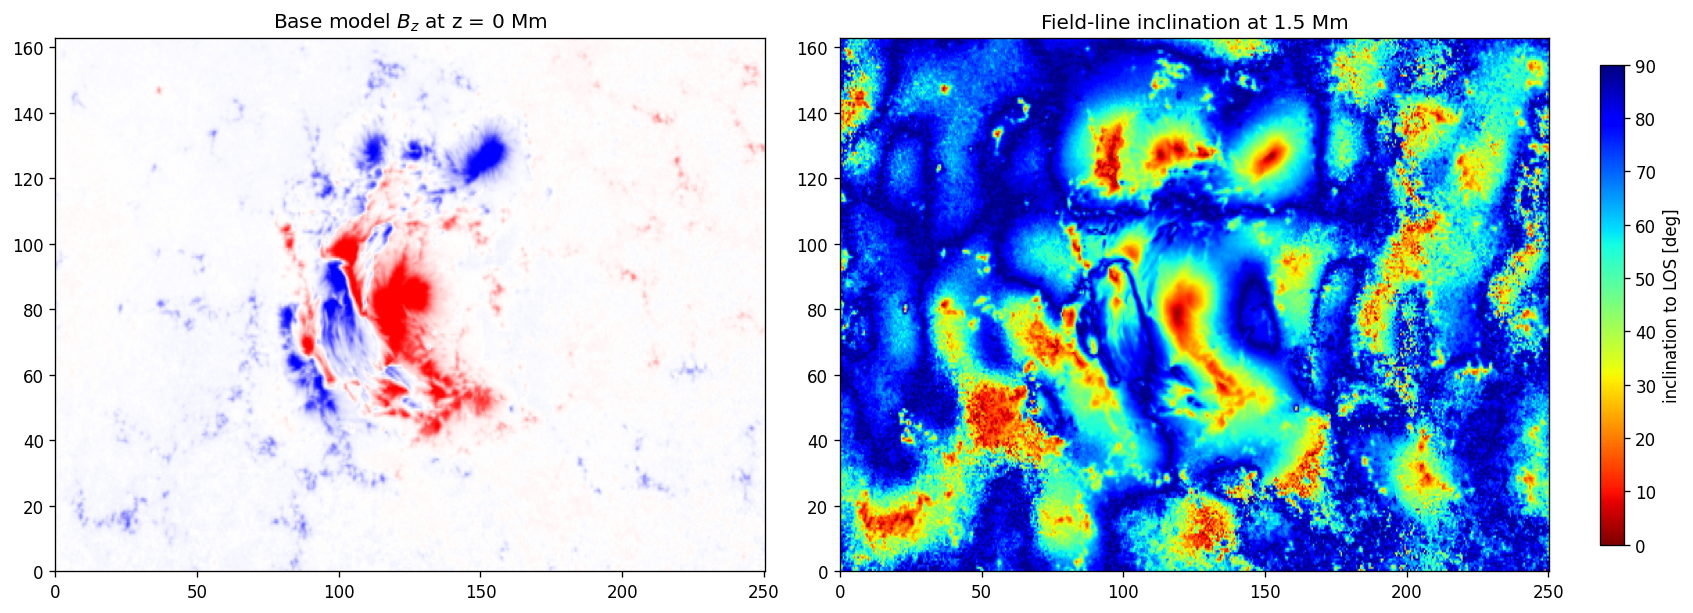

In [94]:
# Base model magnetogram (bottom boundary) and inclination map.
z0 = float(np.min(z_coords))
B_base = plane_at_height(B, x_coords, y_coords, z_coords, z0)
Bz_base = B_base[..., 2]

if reference_map is not None:
    base_bz_map = map_from_model_plane(Bz_base, reference_map, bunit=npz_metadata.get("field_units", "G"), name="RTMAG base Bz")
    inclination_map = map_from_model_plane(inclination, reference_map, bunit="deg", name=f"Field-line inclination at {height_Mm:g} Mm")
    inclination_map.plot_settings["cmap"] = "jet_r"
    inclination_map.plot_settings["norm"] = plt.Normalize(0, 90 if use_absolute_los_angle else 180)

    if case_dir is not None:
        inclination_dir = case_dir / "results" / "inclination"
        inclination_dir.mkdir(parents=True, exist_ok=True)
        inclination_map_path = inclination_dir / f"inclination_height_{height_Mm:g}Mm.fits"
        inclination_map.save(inclination_map_path, overwrite=True)
        print(f"Saved inclination map: {inclination_map_path}")

    vabs = float(np.nanpercentile(np.abs(Bz_base), 99.0))
    fig = plt.figure(figsize=(14, 5), constrained_layout=True)
    ax0 = fig.add_subplot(1, 2, 1, projection=base_bz_map)
    base_bz_map.plot_settings["cmap"] = "bwr"
    base_bz_map.plot_settings["norm"] = plt.Normalize(-vabs, vabs)
    base_bz_map.plot(axes=ax0)
    ax0.set_title(f"Base model $B_z$ at z = {z0:g} {z_coordinate_units}")

    ax1 = fig.add_subplot(1, 2, 2, projection=inclination_map)
    inclination_map.plot(axes=ax1)
    ax1.set_title(f"Inclination at {height_Mm:g} Mm")
    plt.show()
else:
    print("No reference SunPy map found. Falling back to plain Matplotlib axes.")
    extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    vabs = float(np.nanpercentile(np.abs(Bz_base), 99.0))
    ax0.imshow(Bz_base.T, origin="lower", extent=extent, cmap="bwr", vmin=-vabs, vmax=vabs, aspect="auto")
    ax0.set_title(f"Base model $B_z$ at z = {z0:g} {z_coordinate_units}")
    im1 = ax1.imshow(
        inclination.T,
        origin="lower",
        extent=extent,
        cmap="jet_r",
        vmin=0,
        vmax=90 if use_absolute_los_angle else 180,
        aspect="auto",
    )
    ax1.set_title(f"Field-line inclination at {height_Mm:g} Mm")
    fig.colorbar(im1, ax=ax1, label="inclination to LOS [deg]", shrink=0.9)
    plt.show()

## Optional AIA Comparison

If `main.ipynb` has saved the AIA maps, this opens the selected HMI-reprojected AIA map from the same case folder and plots it next to the inclination map using SunPy WCS axes.

In [98]:
if case_dir is not None and reference_map is not None:
    aia_reprojected_path = case_dir / "maps" / "aia_reprojected" / f"aia_{aia_wavelength_for_comparison}_hmi_model_grid.fits"
    if aia_reprojected_path.exists():
        aia_map = sunpy.map.Map(aia_reprojected_path)
        fig = plt.figure(figsize=(14, 5), constrained_layout=True)
        ax0 = fig.add_subplot(1, 2, 1, projection=aia_map)
        aia_map.plot(axes=ax0)
        ax0.set_title(f"AIA {aia_wavelength_for_comparison} Å")

        ax1 = fig.add_subplot(1, 2, 2, projection=inclination_map)
        inclination_map.plot(axes=ax1)
        ax1.set_title(f"Inclination at {height_Mm:g} Mm")
        plt.show()
    else:
        print(f"No saved AIA map found at {aia_reprojected_path}. Run the AIA export cell in main.ipynb first.")
else:
    print("AIA comparison requires an exported case with a reference SunPy map.")

AIA comparison requires an exported case with a reference SunPy map.


## Optional: Inclination at One `(x, y)` Point

Set `x_sample` and `y_sample` in the user-input cell, then rerun from there. The sample coordinates use the same coordinate arrays as the map.

In [96]:
if x_sample is not None and y_sample is not None:
    point = np.array([[float(x_sample), float(y_sample), float(height)]])
    B_point = np.array([
        RegularGridInterpolator((x_coords, y_coords, z_coords), B[..., component])(point)[0]
        for component in range(3)
    ])
    angle_point = inclination_degrees(
        B_point.reshape(1, 1, 3),
        los_vector=los_vector,
        acute=use_absolute_los_angle,
    )[0, 0]
    print(f"B({x_sample}, {y_sample}, {height_Mm} Mm -> z={height:g}) = {B_point}")
    print(f"inclination = {angle_point:.2f} deg")
else:
    print("Set x_sample and y_sample to evaluate one location.")

Set x_sample and y_sample to evaluate one location.


## Height Profile at One Point

This optional section shows how the inclination changes with height at a chosen `(x, y)`. If no sample point is set, it uses the center of the domain.

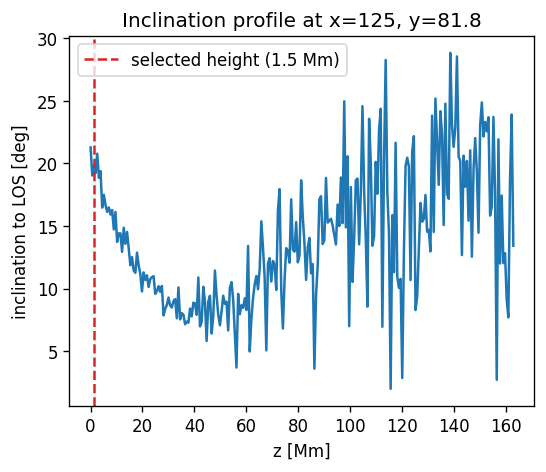

In [97]:
profile_x = float(x_sample) if x_sample is not None else float(x_coords[len(x_coords) // 2])
profile_y = float(y_sample) if y_sample is not None else float(y_coords[len(y_coords) // 2])

profile_points = np.column_stack([
    np.full_like(z_coords, profile_x, dtype=float),
    np.full_like(z_coords, profile_y, dtype=float),
    z_coords,
])
B_profile = np.column_stack([
    RegularGridInterpolator((x_coords, y_coords, z_coords), B[..., component])(profile_points)
    for component in range(3)
])
inclination_profile = inclination_degrees(
    B_profile.reshape(-1, 1, 3),
    los_vector=los_vector,
    acute=use_absolute_los_angle,
).ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(z_coords, inclination_profile)
ax.axvline(height, color="tab:red", linestyle="--", label=f"selected height ({height_Mm:g} Mm)")
ax.set_xlabel(f"z [{z_coordinate_units}]")
ax.set_ylabel("inclination to LOS [deg]")
ax.set_title(f"Inclination profile at x={profile_x:.3g}, y={profile_y:.3g}")
ax.legend()
plt.show()

## Notes for Real Data

- `main.ipynb` writes each run to `examples/analysis_exports/<active-region>/<timestamp>/`.
- The extrapolation lives in `extrapolation/rtmag_extrapolation.npz`.
- The WCS template lives in `maps/hmi/hmi_reference_model_grid.fits`.
- Raw AIA maps live in `maps/aia_raw/`; HMI-reprojected model-grid AIA maps live in `maps/aia_reprojected/`.
- The inclination notebook saves its FITS result to `results/inclination/`, using the HMI reference map metadata with the inclination data array.
- Enter the height you care about as `height_Mm`; the notebook converts it to the z coordinate used by the interpolator and prints the nearest z grid index.

## Notes for Real Data

- `main.ipynb` writes each run to `examples/analysis_exports/<active-region>/<timestamp>/`.
- The extrapolation lives in `extrapolation/rtmag_extrapolation.npz`.
- The WCS template lives in `maps/hmi/hmi_reference_model_grid.fits`.
- Raw AIA maps live in `maps/aia_raw/`; HMI-reprojected model-grid AIA maps live in `maps/aia_reprojected/`.
- The inclination notebook saves its FITS result to `results/inclination/`, using the HMI reference map metadata with the inclination data array.
- Enter the height you care about as `height_Mm`; the notebook converts it to the z coordinate used by the interpolator and prints the nearest z grid index.